## Initialize Networks

## Purpose: 

* Load multiple sources of data
    * Sunny's differential expression 
    * Transcription factor data from `AnimalTFDB v4.0`
* Subset all parameter combinations to: 
    * Differentially Expressed Genes 
    * Transcription Factors Only
* Output the resulting `NetworkX` Directed Graphs as pickled objects

In [52]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.width', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import glob, randomcolor, pickle
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import seaborn as sns

## Thresholds

In [2]:
# thresholds for relative scores for each transcription factor used 
# NOTE: 900 = 90th percentile and so on
relative_threshold = [900, 950, 990]

# thresholds for how far upstream of TSS was used
upstream_thresholds = ["750", "2500", "5000"]

## Load Data

In [3]:
# load predicted mouse transcription factors

mouse_tfs = pd.read_csv("../../../../inputs/mouse_tfs/Mus_musculus_TF.txt", sep="\t")
mouse_tfs = mouse_tfs.set_index("Ensembl")

mouse_tfs.head()

,Species,Symbol,Family,Protein,Entrez_ID
Ensembl,,,,,
ENSMUSG00000063804,Mus_musculus,Lin28b,CSD,ENSMUSP00000078361.7;,380669.0
ENSMUSG00000000093,Mus_musculus,Tbx2,T-box,ENSMUSP00000000095.7;,21385.0
ENSMUSG00000042508,Mus_musculus,Dmtf1,MYB,ENSMUSP00000071815.6;ENSMUSP00000139361.2;ENSM...,23857.0
ENSMUSG00000021604,Mus_musculus,Irx4,Homeobox,ENSMUSP00000134738.2;ENSMUSP00000022095.8;,50916.0
ENSMUSG00000003184,Mus_musculus,Irf3,IRF,ENSMUSP00000146773.2;ENSMUSP00000146383.2;ENSM...,54131.0


In [4]:
# load differential expression data from Sunny 

sunny_diff_exp = pd.read_excel("../../../../inputs/sunny_differential_analysis/mRNA-level-E9-5_Rbfox2_KO-Het.xlsx")
sunny_diff_exp.head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob


In [5]:
# load all of the transcript to gene annotation tables

annotation_tables = {}

for file in sorted(glob.glob("../../5_transcripts_to_genes/outputs/*")): 
    
    annotation_tables[file.split("/")[-1].split(".tsv")[0]] = pd.read_csv(
        file, 
        sep="\t",
        compression="gzip"
    )

#### Remove rows that are not annotated to any genes

In [6]:
for key in annotation_tables:
    tmp = annotation_tables[key].dropna(axis=0)
    annotation_tables[key] = tmp 
    
    tmp.index.size
    

1736975

2702262

714857

1399786

2088167

...

4115608

1947385

331670

539458

135938

## Differential Expression Volcano Plot



In [7]:
sunny_diff_exp.sort_values(by=["log2FoldChange"]).head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
0,ENSMUSG00000017950,219.709303,-4.693934,0.867171,-5.412926,6.200306e-08,2.998404e-05,Hnf4a
1,ENSMUSG00000028357,70.833068,-4.668388,0.678707,-6.878359,6.054593e-12,8.783817e-09,Kif12
2,ENSMUSG00000040891,83.085759,-4.616412,0.574760,-8.031891,9.598124e-16,2.262758e-12,Foxa3
3,ENSMUSG00000017344,325.121362,-4.357324,1.097967,-3.968539,7.231450e-05,8.265767e-03,Vtn
4,ENSMUSG00000020609,246.446133,-4.086230,1.030140,-3.966674,7.288267e-05,8.280525e-03,Apob


In [8]:
sunny_diff_exp.sort_values(by=["padj"]).head()

,ENSMUSG,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id
327,ENSMUSG00000034009,412.067179,2.811033,0.243924,11.524228,9.960137e-31,1.878482e-26,Rxfp1
20,ENSMUSG00000042453,4135.717257,-2.232809,0.212768,-10.494104,9.194560e-26,8.670470e-22,Reln
316,ENSMUSG00000029019,9698.209515,2.139324,0.209991,10.187674,2.250844e-24,1.415031e-20,Nppb
62,ENSMUSG00000033565,15194.864445,-0.994187,0.100046,-9.937295,2.865000e-23,1.350848e-19,Rbfox2
305,ENSMUSG00000019997,3414.818470,1.729922,0.187888,9.207206,3.347254e-20,1.262584e-16,Ctgf


<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, "Volcano Plot of Sunny's Differential Expression Analysis")

Text(0, 0.5, '-log10(Adjusted P-Value)')

Text(0.5, 0, 'log2(Fold-Change)')

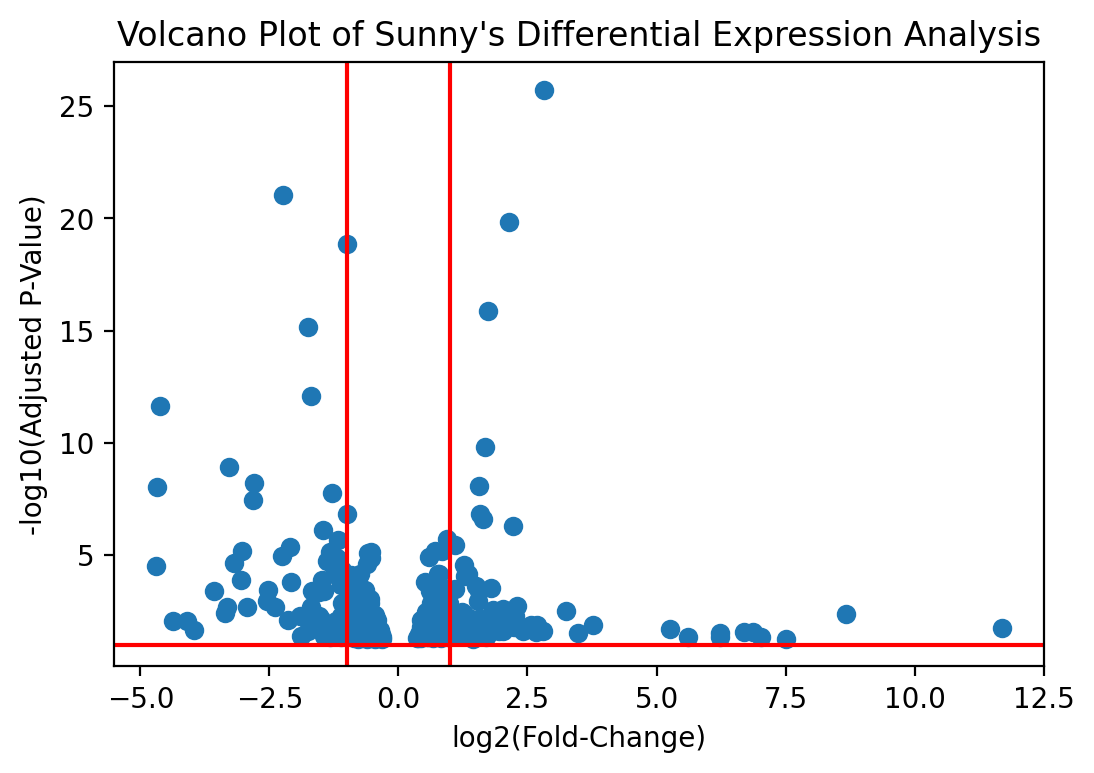

In [9]:
plt.figure(dpi=200)

plt.title("Volcano Plot of Sunny's Differential Expression Analysis")
plt.scatter(x=sunny_diff_exp["log2FoldChange"], y=-np.log10(sunny_diff_exp["padj"]))

plt.ylabel("-log10(Adjusted P-Value)")
plt.xlabel("log2(Fold-Change)")

plt.axvline(1, color="red", label="1")
plt.axvline(-1, color="red", label="-1")

plt.axhline(1, color='red', label="1")

#### Save differential expression `ENSEMBL` IDs

In [10]:
diff_gene_ids = sunny_diff_exp["ENSMUSG"].tolist()

print(diff_gene_ids,end="\t")

['ENSMUSG00000017950', 'ENSMUSG00000028357', 'ENSMUSG00000040891', 'ENSMUSG00000017344', 'ENSMUSG00000020609', 'ENSMUSG00000032083', 'ENSMUSG00000042448', 'ENSMUSG00000071551', 'ENSMUSG00000074768', 'ENSMUSG00000045518', 'ENSMUSG00000019368', 'ENSMUSG00000038700', 'ENSMUSG00000029195', 'ENSMUSG00000044254', 'ENSMUSG00000026398', 'ENSMUSG00000005320', 'ENSMUSG00000020679', 'ENSMUSG00000029556', 'ENSMUSG00000037025', 'ENSMUSG00000005681', 'ENSMUSG00000042453', 'ENSMUSG00000024391', 'ENSMUSG00000045991', 'ENSMUSG00000030088', 'ENSMUSG00000026227', 'ENSMUSG00000026934', 'ENSMUSG00000073409', 'ENSMUSG00000032796', 'ENSMUSG00000031654', 'ENSMUSG00000031883', 'ENSMUSG00000064225', 'ENSMUSG00000028373', 'ENSMUSG00000055409', 'ENSMUSG00000038692', 'ENSMUSG00000021209', 'ENSMUSG00000034450', 'ENSMUSG00000025196', 'ENSMUSG00000079654', 'ENSMUSG00000024907', 'ENSMUSG00000048126', 'ENSMUSG00000020080', 'ENSMUSG00000102692', 'ENSMUSG00000074575', 'ENSMUSG00000018822', 'ENSMUSG00000024986', 'ENSMUSG0

## Construct Edgelist

Need to make sure that transcription factor names coming from Sunny's list actually have `GENCODE` IDs. 

This is because we want to avoid situations where the TF in question is named something else in `GENCODE` so we're missing links. 

In [11]:
for key in annotation_tables: 
    # don't get repeat entries due to different thresholds used for annotation
    if "5000" in key: 
        annotation_tables[key]["1"].unique()

array(['MEF2A'], dtype=object)

array(['RORA'], dtype=object)

array(['RREB1'], dtype=object)

array(['ELK4'], dtype=object)

array(['NFIC'], dtype=object)

...

array(['NR4A1'], dtype=object)

array(['PBX3'], dtype=object)

array(['TCF7L1'], dtype=object)

array(['MAZ'], dtype=object)

array(['NR6A1'], dtype=object)

The above `TFs` besides `RORA` are part of `GENCODE`. 

`RORA` is from `RefSeq`. 

In [12]:
individual_edge_lists = {}

for key in annotation_tables:
    
    key 
    
    # rename columns
    tmp = annotation_tables[key][["1", "Gene name", "Gene stable ID", "2"]].rename(
        columns={"1":"TF", "Gene name":"Target", "Gene stable ID": "Target ID", "2": "Relative Score"}
    )

    # make gene names lowercase to avoid weird issues where there are duplicate nodes (due to capitalization issues)
    tmp["TF"] = tmp["TF"].str.lower()
    tmp["Target"] =  tmp["Target"].str.lower()
    
    # for each threshold in relative scoring
    for threshold in relative_threshold: 
        
        # subset relative scores for thresholds
        tmp = tmp[tmp["Relative Score"]>threshold]
        
        # create key for edge list 
        edge_list_key = "{}_relative_score_percentile_{}".format(key, threshold)
        
        # get the unique TF-target pairs 
        individual_edge_lists[edge_list_key] = tmp[["TF", "Target", "Target ID"]].drop_duplicates()
    

'MA0052.4.upstream_2500'

'MA0052.4.upstream_5000'

'MA0052.4.upstream_750'

'MA0071.1.upstream_2500'

'MA0071.1.upstream_5000'

...

'MA1522.1.upstream_5000'

'MA1522.1.upstream_750'

'MA1541.1.upstream_2500'

'MA1541.1.upstream_5000'

'MA1541.1.upstream_750'

Concatenate all lists that have the same upstream parameter and relative score threshold

In [13]:
final_edge_lists = {}

for score_threshold in relative_threshold: 
    for upstream_threshold in upstream_thresholds:
        edge_list_key = "upstream_{}_score_{}".format(upstream_threshold, score_threshold)
        final_edge_lists[edge_list_key] = []
        
        for key in individual_edge_lists: 
            if str(score_threshold) in key and str(upstream_threshold) in key: 
                final_edge_lists[edge_list_key].append(individual_edge_lists[key])
    
# concatenate all the pandas dataframes 

for key in final_edge_lists:
    key
    final_edge_lists[key] = pd.concat(final_edge_lists[key])
    final_edge_lists[key] = final_edge_lists[key].set_index("Target ID")
    final_edge_lists[key].index.size


'upstream_750_score_900'

162423

'upstream_2500_score_900'

240359

'upstream_5000_score_900'

...

7381

'upstream_2500_score_990'

13964

'upstream_5000_score_990'

20648

Check number of gene targets per combination of parameters

In [14]:
unique_gene_numbers = []

for key in final_edge_lists: 
    key
    final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append(final_edge_lists[key]["Target"].unique().size)
    
unique_gene_numbers

'upstream_750_score_900'

19465

'upstream_2500_score_900'

19528

'upstream_5000_score_900'

...

'upstream_2500_score_990'

9058

'upstream_5000_score_990'

11613

[19465, 19528, 19584, 17737, 19296, 19535, 5768, 9058, 11613]

<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, 'Number of Unique Protein-coding Genes')

([<matplotlib.axis.XTick at 0x7f6fd736e2e0>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

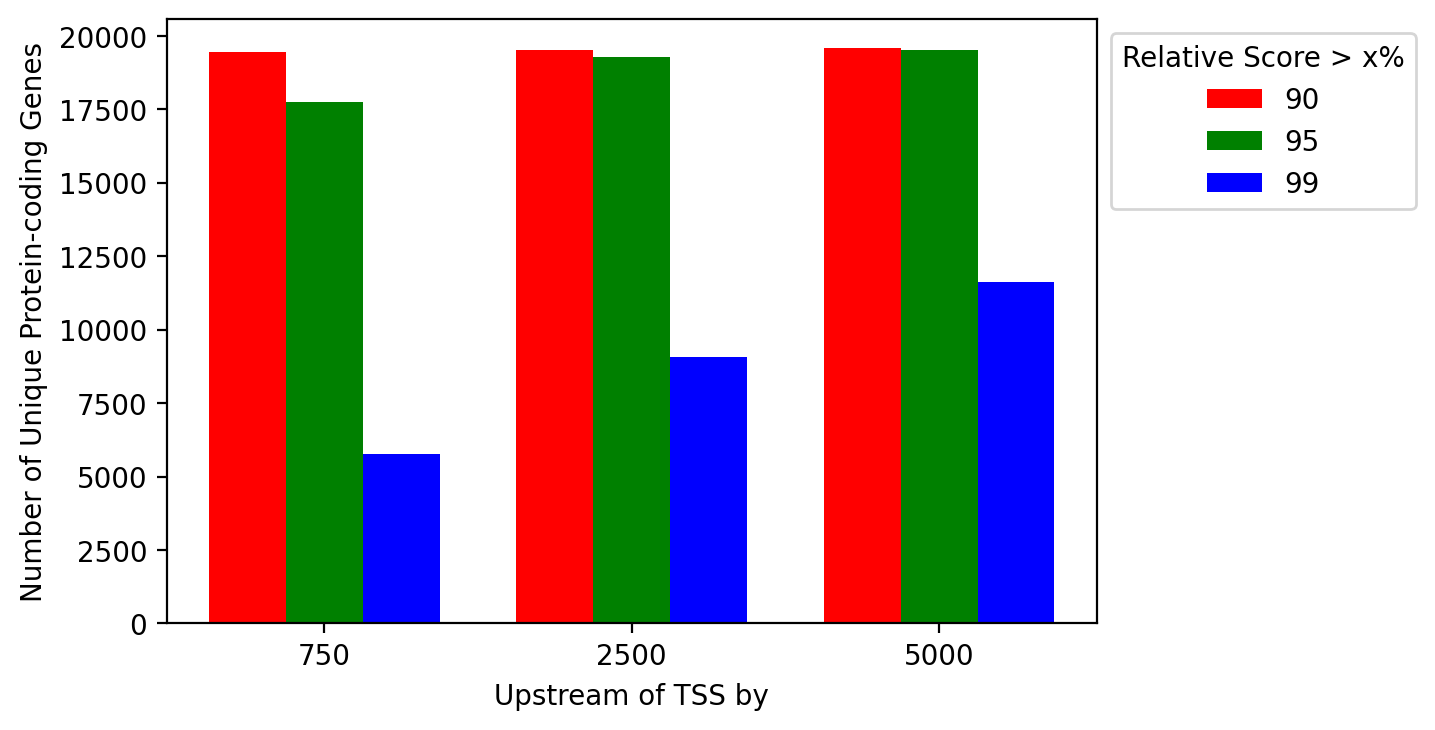

In [15]:
plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('Number of Unique Protein-coding Genes')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

## GO Enrichment

In [16]:
genes_for_GO = final_edge_lists['upstream_750_score_990']["Target"].unique().tolist()

for item in genes_for_GO: 
    print(item, end = "\t")

tbp	psmb1	bhlhe40	6430548m08rik	sec24d	zfpm2	glrp1	plppr3	nckap5	amn1	tuba1a	nsd1	dip2b	myo5a	galnt2l	gm49450	prtn3	bex6	col6a1	col6a2	ergic1	ifrd1	celf2	scrib	aven	rps6ka1	psap	ndrg2	trim28	pcdhac1	sptbn4	dnajc7	cox6c	lamp2	serinc3	myh4	smpdl3a	dusp6	obscn	glrx	4930578i06rik	pabpn1	laptm4b	pak2	lmln	paxbp1	msrb2	cfb	lipf	eif3a	katnal2	gigyf2	bok	acbd3	ptpn14	ubox5	hdc	mrgbp	ppm1l	casp6	ccdc107	ssu72	gbp8	pcolce	fbxo24	emc3	ttc23	gm42742	aldoa	art1	gas6	mfap3l	crispld2	pou2af1	me1	bsn	acsl3	nfatc1	fancd2	prex1	dock4	ppp1r16a	heca	trpm3	ptprm	smpx	trrap	sufu	actr1a	h2-aa	mycbpap	aox3	tm6sf1	naa25	camk4	bcor	hnrnpul1	ago2	gramd1b	lzts3	elmsan1	tgtp2	misp	pdgfa	rdh7	rnf126	pcdhac2	pcdha12	metap2	coro2b	bsdc1	gtdc1	snx10	rnf125	cystm1	prop1	akt2	mtus1	morn4	prss54	zbtb6	rnf216	utp14b	pcdhb17	sipa1l1	zfp444	ppm1e	kcns3	themis	oprd1	olfr56	cog7	rp1l1	npsr1	gm12185	tmtc1	clec4a1	tmem248	gpr141	shisa6	ccser2	amy1	tgtp1	nyap2	susd6	irs1	atp8b2	efemp2	pcdha1	alg13	etnppl	ms4a10	gtf2ird1	atxn7l3	

#### Results

Doesn't seem like it actually means anything 

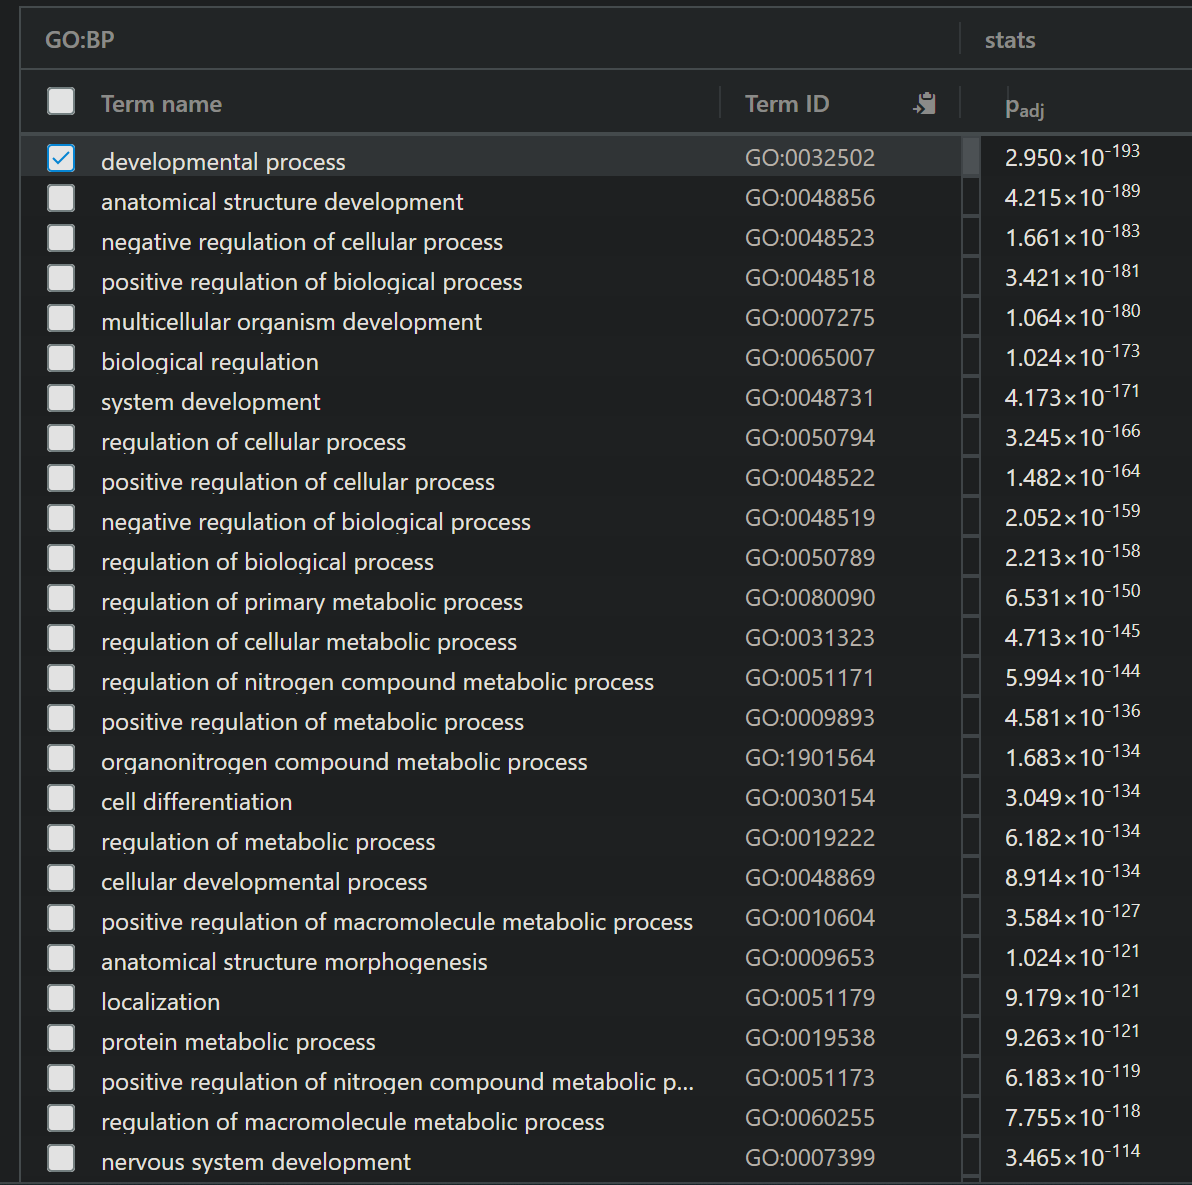

## Subset to Transcription Factors & Initialize those Networks

In [17]:
mouse_tfs.head()

,Species,Symbol,Family,Protein,Entrez_ID
Ensembl,,,,,
ENSMUSG00000063804,Mus_musculus,Lin28b,CSD,ENSMUSP00000078361.7;,380669.0
ENSMUSG00000000093,Mus_musculus,Tbx2,T-box,ENSMUSP00000000095.7;,21385.0
ENSMUSG00000042508,Mus_musculus,Dmtf1,MYB,ENSMUSP00000071815.6;ENSMUSP00000139361.2;ENSM...,23857.0
ENSMUSG00000021604,Mus_musculus,Irx4,Homeobox,ENSMUSP00000134738.2;ENSMUSP00000022095.8;,50916.0
ENSMUSG00000003184,Mus_musculus,Irf3,IRF,ENSMUSP00000146773.2;ENSMUSP00000146383.2;ENSM...,54131.0


In [18]:
joined_tf_tf_edge_lists = {}

# join the edge lists for each parameter combination with the TF table above
for key in final_edge_lists: 
    
    tmp =  final_edge_lists[key].join(mouse_tfs, how="inner")
    
    joined_tf_tf_edge_lists[key] =tmp 
    
    tmp.index.unique().size
    tmp.head()
    

1541

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
ENSMUSG00000000078,mef2a,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,rora,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,elk4,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,nfic,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,jun,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0


1548

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
ENSMUSG00000000078,mef2a,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,rora,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,elk4,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,nfic,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,jun,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0


1550

...

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
ENSMUSG00000000078,maz,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000094,maz,tbx4,Mus_musculus,Tbx4,T-box,ENSMUSP00000103682.2;ENSMUSP00000000096.6;ENSM...,21387.0
ENSMUSG00000000134,nr2f2,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0
ENSMUSG00000000134,maz,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0
ENSMUSG00000000552,maz,zfp385a,Mus_musculus,Zfp385a,zf-C2H2,ENSMUSP00000130176.2;ENSMUSP00000155498.2;ENSM...,29813.0


770

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
ENSMUSG00000000078,nr4a1,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,maz,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000094,maz,tbx4,Mus_musculus,Tbx4,T-box,ENSMUSP00000103682.2;ENSMUSP00000000096.6;ENSM...,21387.0
ENSMUSG00000000134,nr2f2,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0
ENSMUSG00000000134,maz,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0


959

,TF,Target,Species,Symbol,Family,Protein,Entrez_ID
ENSMUSG00000000078,nr4a1,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000078,maz,klf6,Mus_musculus,Klf6,zf-C2H2,ENSMUSP00000000080.7;,23849.0
ENSMUSG00000000094,maz,tbx4,Mus_musculus,Tbx4,T-box,ENSMUSP00000103682.2;ENSMUSP00000000096.6;ENSM...,21387.0
ENSMUSG00000000134,nr2f2,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0
ENSMUSG00000000134,maz,tfe3,Mus_musculus,Tfe3,bHLH,ENSMUSP00000111343.2;ENSMUSP00000111342.3;ENSM...,209446.0


In [19]:
tf_tf_networks = {}

# create directed NetworkX graph clearly specifying target and source
for key in joined_tf_tf_edge_lists: 
    tmp = nx.from_pandas_edgelist(joined_tf_tf_edge_lists[key], source="TF", target="Target", create_using=nx.DiGraph())
    tf_tf_networks[key] = tmp
    
#     plt.figure(dpi=300)
#     plt.title(key)
#     nx.draw(tmp, pos= nx.spring_layout(tmp))
#     plt.show()

## Subset to Differentially Expressed Genes & Initialize those Networks

In [20]:
joined_final_edge_lists = {}

# join each edge list with differential gene ids to subset
for key in final_edge_lists: 
    key
    
    tmp = final_edge_lists[key].join(pd.DataFrame(diff_gene_ids).set_index(0), how="inner")
    
    joined_final_edge_lists[key] = tmp 
    
    tmp.index.size

'upstream_750_score_900'

2936

'upstream_2500_score_900'

4075

'upstream_5000_score_900'

...

161

'upstream_2500_score_990'

306

'upstream_5000_score_990'

452

#### Visualize % of Differentially Expressed Genes that Are Predicted as TF Targets

This is based on `JASPAR`. 

As well, this is meant to be across all parameter combinations

'upstream_750_score_900'

312

'upstream_2500_score_900'

312

'upstream_5000_score_900'

...

225

<Figure size 1200x800 with 0 Axes>

Text(0.5, 0, 'Upstream of TSS by')

Text(0, 0.5, '% of Diff. Expression Genes as TF Targets ')

([<matplotlib.axis.XTick at 0x7f6f6d294820>,
 [Text(0.25, 0, '750'), Text(1.25, 0, '2500'), Text(2.25, 0, '5000')])

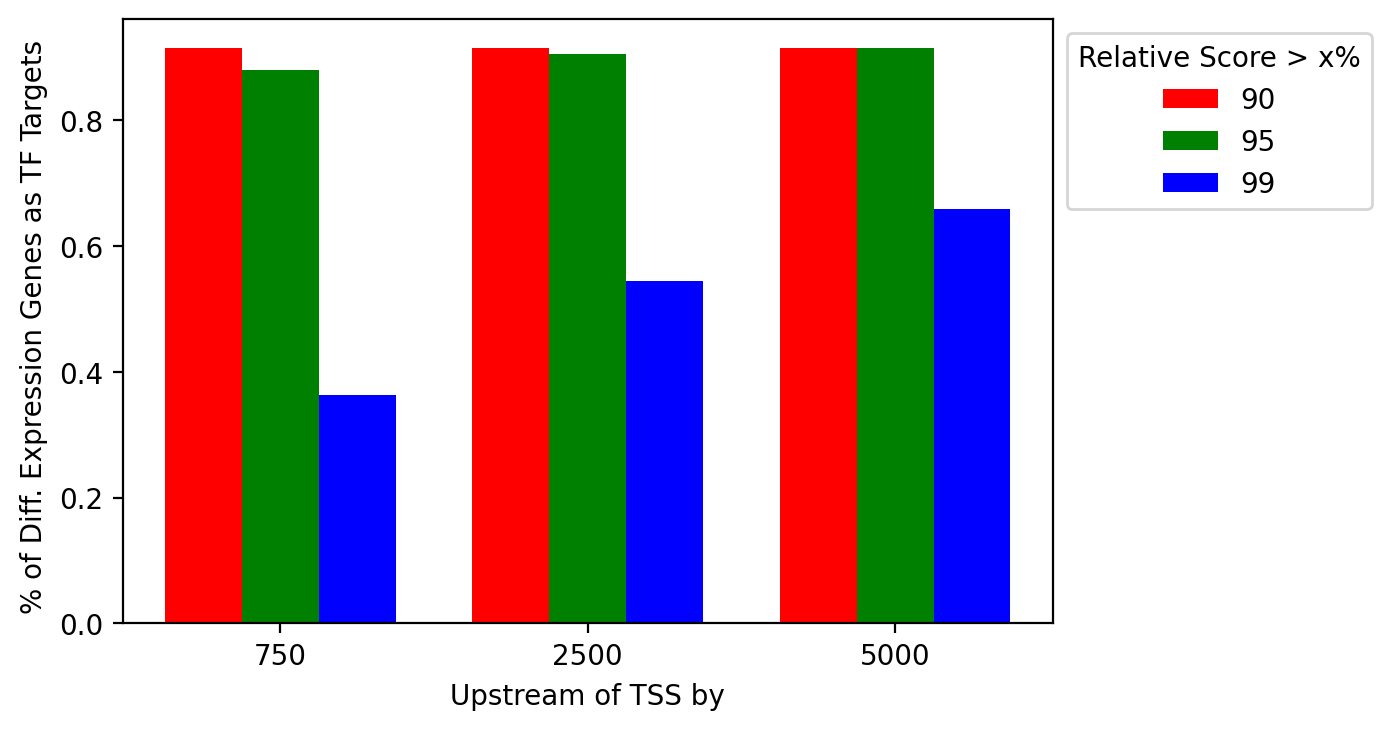

In [21]:
unique_gene_numbers = []

for key in joined_final_edge_lists: 
    key
    joined_final_edge_lists[key]["Target"].unique().size
    unique_gene_numbers.append((joined_final_edge_lists[key]["Target"].unique().size)/len(diff_gene_ids))
    

plt.figure(dpi=200)

N = 3
ind = np.arange(N) 
width = 0.25
  
bar1 = plt.bar(ind, unique_gene_numbers[0:3], width, color = 'r')
bar2 = plt.bar(ind+width, unique_gene_numbers[3:6], width, color='g')
bar3 = plt.bar(ind+width*2, unique_gene_numbers[6:9], width, color = 'b')
  
plt.xlabel("Upstream of TSS by")
plt.ylabel('% of Diff. Expression Genes as TF Targets ')
  
plt.xticks(ind+width,["750", "2500", "5000"])
plt.legend( (bar1, bar2, bar3), ('90', '95', '99'), title="Relative Score > x%", bbox_to_anchor=(1,1))
plt.show()

In [22]:
for key in joined_final_edge_lists: 
    key
    joined_final_edge_lists[key]["TF"].value_counts().head()

'upstream_750_score_900'

sox4     284
hic1     271
maz      259
elk4     210
nr2f2    190
Name: TF, dtype: int64

'upstream_2500_score_900'

sox4      309
hic1      307
maz       289
hmbox1    268
nr2f2     259
Name: TF, dtype: int64

'upstream_5000_score_900'

...

maz      74
sox4     35
hic1     12
nr2f2    12
nfic      8
Name: TF, dtype: int64

'upstream_2500_score_990'

maz      110
sox4      62
hic1      27
nfic      24
nr2f2     21
Name: TF, dtype: int64

'upstream_5000_score_990'

maz      140
sox4      81
hic1      45
nr2f2     43
nfic      41
Name: TF, dtype: int64

In [23]:
joined_final_edge_lists[key].head()

,TF,Target
ENSMUSG00000000142,nfic,axin2
ENSMUSG00000000142,sox4,axin2
ENSMUSG00000000142,maz,axin2
ENSMUSG00000000320,maz,alox12
ENSMUSG00000000489,nr2f2,pdgfb


### Plot number of differentially expressed genes each `TF` binds to based on `JASPAR` predictions

In [45]:
concat_list = []

for key in joined_final_edge_lists: 
    tmp = joined_final_edge_lists[key].groupby("TF").count()
    tmp["Parameter Combination"] = "-".join([key.split("_")[1], key.split("_")[3]])
    
    concat_list.append(tmp)

tf_num_diff_genes_targetting = pd.concat(concat_list)

tf_num_diff_genes_targetting.head()


,Target,Parameter Combination
TF,,
atf7,22,750-900
creb3l1,1,750-900
cux1,54,750-900
elk4,210,750-900
esrra,86,750-900


In [46]:
combination_order = pd.api.types.CategoricalDtype(
    [
        "750-900",
        "750-950",
        "750-990",
        "2500-900",
        "2500-950",
        "2500-990",
        "5000-900",
        "5000-950",
        "5000-990"
    ], 
    ordered=True
)

combination_order

tf_num_diff_genes_targetting["Parameter Combination"] = tf_num_diff_genes_targetting["Parameter Combination"].astype(combination_order)

tf_num_diff_genes_targetting.dtypes

tf_num_diff_genes_targetting = tf_num_diff_genes_targetting.sort_values("Parameter Combination")

tf_num_diff_genes_targetting.head()

CategoricalDtype(categories=['750-900', '750-950', '750-990', '2500-900', '2500-950', '2500-990', '5000-900', '5000-950', '5000-990'], ordered=True)

Target                      int64
Parameter Combination    category
dtype: object

,Target,Parameter Combination
TF,,
atf7,22,750-900
tcf7l2,177,750-900
tcf7l1,34,750-900
stat6,150,750-900
sox4,284,750-900


In [50]:
sox4_summary = tf_num_diff_genes_targetting[tf_num_diff_genes_targetting.index=="sox4"]
sox4_summary

,Target,Parameter Combination
TF,,
sox4,284,750-900
sox4,181,750-950
sox4,35,750-990
sox4,309,2500-900
sox4,245,2500-950
sox4,62,2500-990
sox4,312,5000-900
sox4,282,5000-950
sox4,81,5000-990


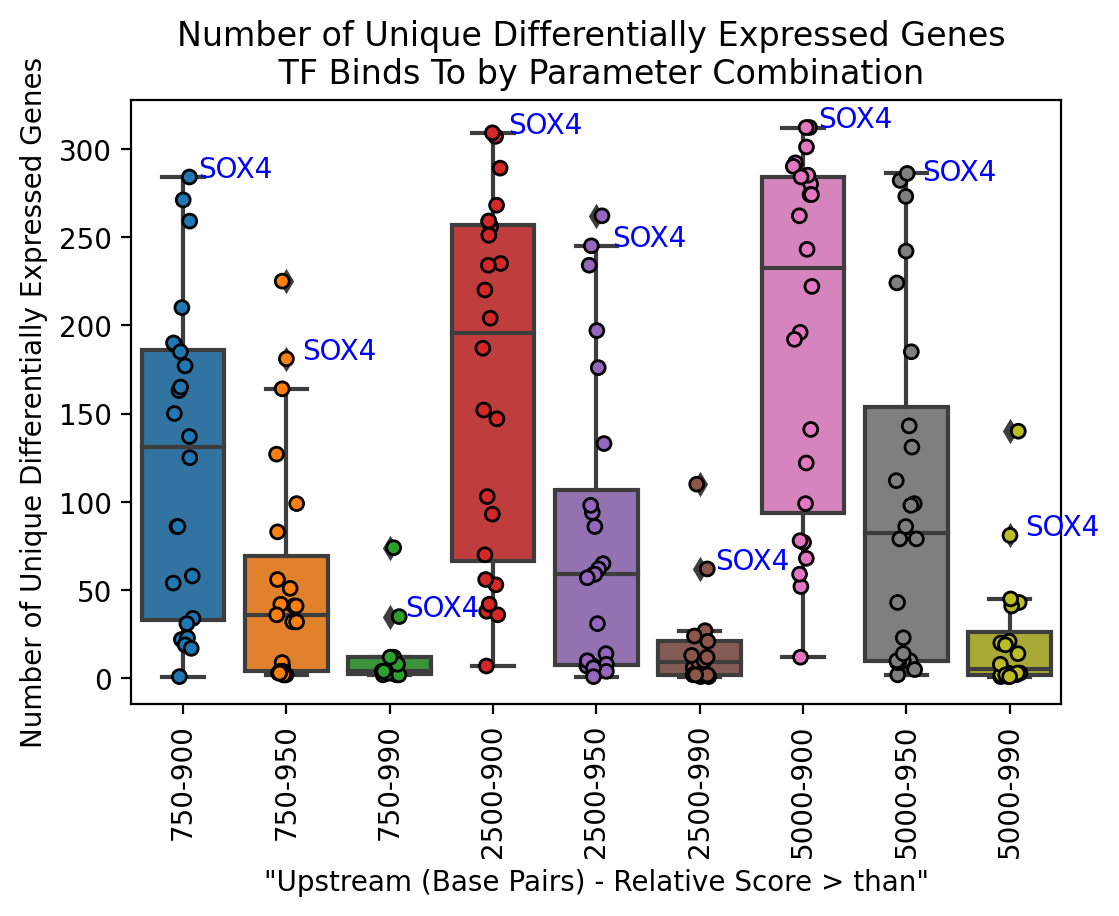

In [66]:
_=plt.figure(dpi=200)
_=plt.title("Number of Unique Differentially Expressed Genes \n TF Binds To by Parameter Combination")
_=sns.boxplot(x="Parameter Combination", y="Target", data=tf_num_diff_genes_targetting)
_=sns.stripplot(x="Parameter Combination", y="Target", data=tf_num_diff_genes_targetting, edgecolor="black", linewidth=1)
_=plt.xticks(rotation=90)

_=plt.xlabel('"Upstream (Base Pairs) - Relative Score > than"')
_=plt.ylabel("Number of Unique Differentially Expressed Genes")


for counter, num_genes in enumerate(sox4_summary["Target"].to_list()): 
    
    _= plt.text(counter+0.15, num_genes, "SOX4", color="blue")

plt.savefig("/home/jve4pt/num_differential_genes_sox4_highlighted_november_16_2023.png", dpi=200, bbox_inches = "tight")

#### Initialize differential expression `TF` networks

In [ ]:
differential_expression_tf_networks = {}

# create directed NetworkX graphs specifying source and target 

for key in joined_final_edge_lists: 
    tmp = nx.from_pandas_edgelist(joined_final_edge_lists[key], source="TF", target="Target", create_using=nx.DiGraph())
    differential_expression_tf_networks[key] = tmp
    
#     plt.figure(dpi=300)
#     plt.title(key)
#     nx.draw(tmp, pos= nx.spring_layout(tmp))
#     plt.show()

## Output Networks in Pickled Format

In [ ]:
for key in differential_expression_tf_networks: 
    
    pickle.dump(
        differential_expression_tf_networks[key],
        open(
            "../../../../outputs/pickled_networks/differential_expression_tf_networks/{}.networkx_graph".format(key), 
            'wb'
        )
    )

In [ ]:
for key in tf_tf_networks: 
    
    pickle.dump(
        
        tf_tf_networks[key],
        open(
            "../../../../outputs/pickled_networks/tf_tf_networks/{}.networkx_graph".format(key), 
            'wb'
        )
        
    )